In [1]:
import torch
import pickle
from torch import nn
from tqdm import tqdm
from mydataloader2 import *
from animation_marking import animation_double,line_plot
from seq2seq import Seq2Seq

In [2]:
with open(r"E:\bishe\work\results\posearray.pkl","rb")as f:
    circular=pickle.load(f)


In [ ]:
batch_size = 64
train_steps = 20
input_size = 6
de_input_size = 3
hidden_size = 256
linear_size = 128
output_size = 3
lr = 0.005
num_layer = 2
pred_steps = 10
test_num = 20
train_ratio = 0.8
epochs = 500
type = "lstm"

scaler = StandardScaler()
scaler.fit(circular)
circular_trans=scaler.transform(circular)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_loder=MyDataLoader(circular_trans,train_ratio,test_num,batch_size,train_steps,pred_steps)
net=Seq2Seq(input_size,de_input_size,hidden_size,output_size,num_layer,linear_size,pred_steps,train_steps,type).to(device)


In [ ]:
# net = torch.load("model.pth", map_location=device, weights_only=False)
net.load_state_dict(
    torch.load("time_seq_best.opt", map_location=device, weights_only=False)
)

<All keys matched successfully>

In [ ]:
test_loder=data_loder.test_iter(6)
mutil_steps_pred=pred_time_seq(test_loder,net,device,test_num,num_layer,hidden_size,type)
mutil_steps_pred=scaler.inverse_transform(mutil_steps_pred,train_steps,pred_steps,output_size,test_num)
print(mutil_steps_pred[0].shape)

(111, 10, 3)


In [ ]:
mutil_steps_pred[0][20]

array([[36.22478312, 32.3252345 ,  8.41180564],
       [36.17188834, 32.13308317,  8.29528739],
       [36.14765707, 31.9678156 ,  8.21608487],
       [36.15593443, 31.81840829,  8.16611428],
       [36.19665759, 31.70582882,  8.15266892],
       [36.27742939, 31.61831863,  8.17286276],
       [36.38273559, 31.56499382,  8.21992309],
       [36.52496627, 31.53947912,  8.30010913],
       [36.6798492 , 31.54323104,  8.39635639],
       [36.86700863, 31.5770967 ,  8.52148799]])

In [ ]:
circular[5073+0][20:30,1:4]


array([[36.23253195, 32.31206339,  8.4010186 ],
       [36.19698365, 32.09817958,  8.27267468],
       [36.19457749, 31.90727933,  8.17684996],
       [36.2269906 , 31.71494037,  8.09928548],
       [36.28039452, 31.5417811 ,  8.03957762],
       [36.35888357, 31.37276213,  7.99822401],
       [36.45034248, 31.22265672,  7.97354994],
       [36.55950696, 31.07901804,  7.96096   ],
       [36.68026651, 30.95914265,  7.96399629],
       [36.82061044, 30.84337677,  7.98084653]])

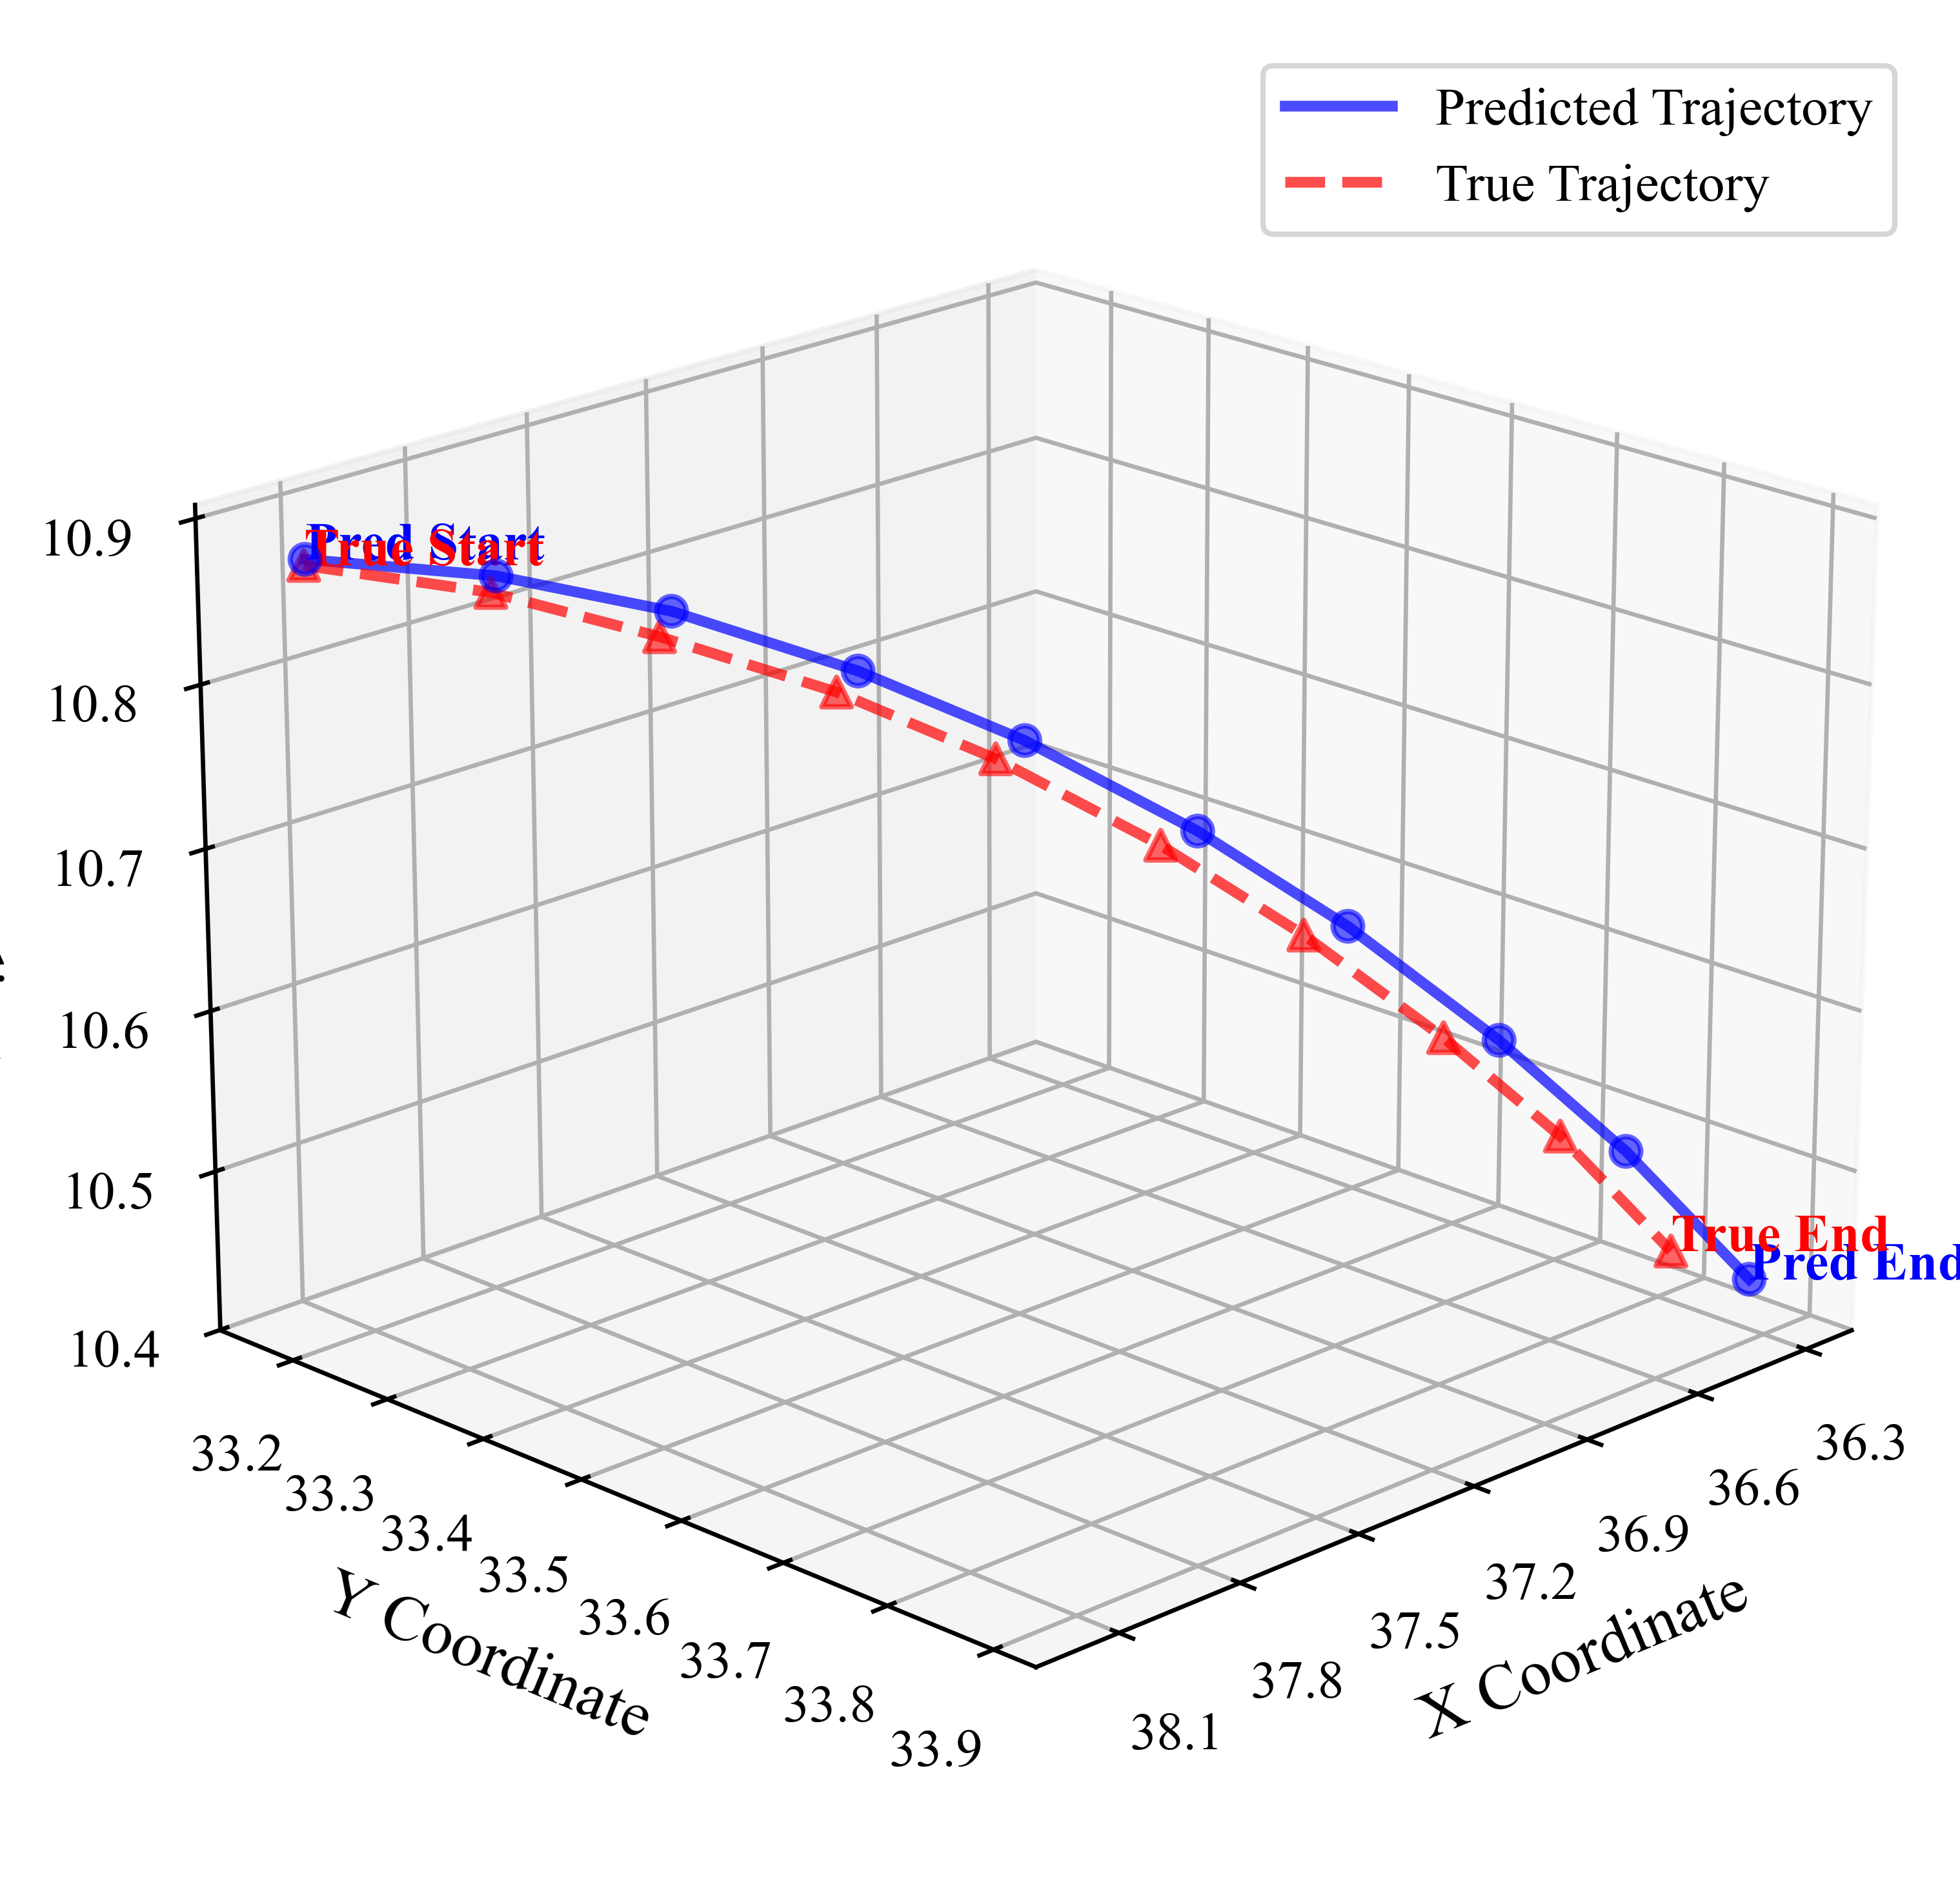

In [ ]:
line_plot(mutil_steps_pred,circular,0,5073,60)

In [ ]:
# test_start_idx = len(circular) - test_num
# for i in range(test_num):
#     dataset1=circular[i+test_start_idx]
#     dataset2=mutil_steps_pred[i]
#     animation_double(i,dataset1,dataset2)